# Set up workspace

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import sys

In [2]:
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')

In [3]:
from load_ensembles import *
from load_gridcell_areas import *
from plotting_settings import *
from FDR_analysis import *

In [4]:
path_in='/glade/work/czarakas/coupled_PPE/data/data_for_figures/'

# Load data

In [5]:
ds_Ts = xr.open_dataset(path_in+'annual_means/delta_TSKIN_Annual_mean_coupled.nc')['TSKIN']
pvals_Ts=xr.open_dataset(path_in+'annual_means/pval_TSKIN_Annual_mean_coupled.nc')['pval']

In [6]:
ds_P = xr.open_dataset(path_in+'annual_means/delta_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']
pvals_P=xr.open_dataset(path_in+'annual_means/pval_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['pval']

In [7]:
ds_ref_P=xr.open_dataset(path_in+'annual_means/ref_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']
ds_ref_Ts=xr.open_dataset(path_in+'annual_means/ref_TSKIN_Annual_mean_coupled.nc')['TSKIN']

In [8]:
landweights2_atm=landweights2.reindex_like(ds_ref_P, method='nearest',tolerance=0.05)
landweights2_lnd=landweights2

# Figure S8

In [9]:
#without FDR analysis
pct_change_Ts=(((pvals_Ts<=0.05))*landweights2).sum(dim=['lat','lon'])*100
pct_change_P=(((pvals_P<=0.05))*landweights2).sum(dim=['lat','lon'])*100

In [10]:
#with FDR analysis

K=(landweights2.values.flatten()>0).sum()
sig_change_Ts=calculate_sig_changes_FDR(pvals_Ts, 
                              K=K,
                              alpha_global=0.05)
sig_change_P=calculate_sig_changes_FDR(pvals_P, 
                              K=K,
                              alpha_global=0.05)

pct_change_Ts=((sig_change_Ts)*landweights2).sum(dim=['lat','lon'])*100
pct_change_P=((sig_change_P)*landweights2).sum(dim=['lat','lon'])*100

/glade/u/ssg/ch/usr/jupyterhub/envs/pangeo-2019.09.12/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in greater
  This is separate from the ipykernel package so we can avoid doing imports until


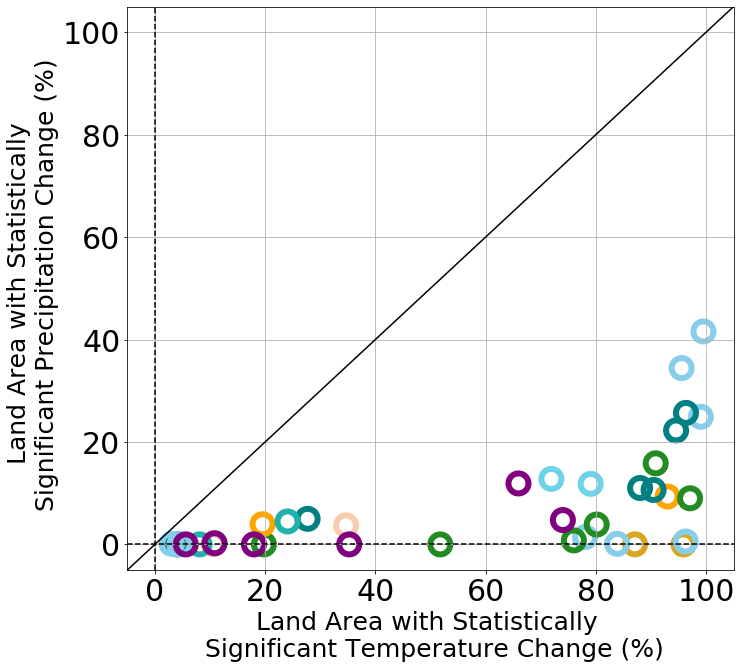

In [11]:
plt.rcParams.update({'font.size': 30})

plt.figure(figsize=(11,10))

#plt.scatter(pct_change_Ts[zeta_ind], pct_change_P[zeta_ind], s=400, 
#            c=np.array(colors)[zeta_ind],
#            linewidth=6)
plt.scatter(pct_change_Ts, pct_change_P, s=400, 
            edgecolors=colors,facecolors='none',linewidth=6)
plt.grid()
plt.axhline(y=0,linestyle='--',color='k')
plt.axvline(x=0,linestyle='--',color='k')
plt.xlabel('Land Area with Statistically \n Significant Temperature Change (%)',
          fontsize=25)
plt.ylabel('Land Area with Statistically \n Significant Precipitation Change (%)',
          fontsize=25)
plt.plot([-5,105],[-5,105],'-k')
plt.xlim([-5,105])
plt.ylim([-5,105])
plt.tight_layout()
#plt.savefig('Figures/Figure_S8.pdf')